Q1: DAXPY LOOP
X[i] = a*X[i] + Y[i]

In [3]:
N = 2 ** 16
MAX_THREADS = 16

In [13]:
%%writefile daxpy.cpp

#include <iostream>
#include <omp.h>
#include <vector>

using namespace std;


#define N (1<<16)


int main(int argc, char* argv[]){
  int threads = atoi(argv[1]);
  vector <double> X(N), Y(N);

  double a = 2.5;

  for(int i=0; i< N; i++){
    X[i] = i * 1.0;
    Y[i] = i * 2.0;
  }

  omp_set_num_threads(threads);

  double start = omp_get_wtime();

  #pragma omp parallel for
  for(int i=0; i< N; i++){
    X[i] = a*X[i] + Y[i];
  }

  double end = omp_get_wtime();
  cout << end - start;
  return 0;
}

Overwriting daxpy.cpp


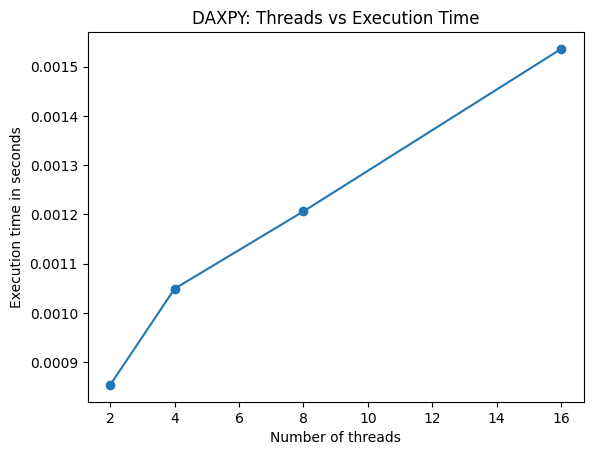

In [14]:
import subprocess
import matplotlib.pyplot as plt


!g++ -fopenmp daxpy.cpp -o daxpy

threads_list = []
time_list = []

t = 2
while t <= MAX_THREADS:
  result = subprocess.check_output(["./daxpy", str(t)])
  time_taken = float(result.decode().strip()) # bytes -> string -> removes whitespaces #

  threads_list.append(t)
  time_list.append(time_taken)
  t*=2

plt.figure()
plt.plot(threads_list, time_list, marker= 'o')
plt.xlabel("Number of threads")
plt.ylabel("Execution time in seconds")
plt.title("DAXPY: Threads vs Execution Time")
plt.show()

The execution time increases with the number of threads because the DAXPY operation has *very low computational intensity*.

For small vector sizes, the overhead of thread creation, synchronization, and memory access dominates the computation time. As a result, increasing the number of threads leads to higher overhead and increased execution time instead of speedup
